# Checkpoint Winrate Analysis

This notebook parses a training output file produced by `logic/training.py`, extracts checkpoint evaluation win counts, computes win-rate statistics, and plots:

1. `current vs random` and `current vs heuristic` in one plot.
2. `current vs previous` in a separate plot (binary outcome per matchup).

In [51]:
from pathlib import Path
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_rows", 200)

In [59]:
OUTPUT_DIR = Path("output")
if not OUTPUT_DIR.exists():
    OUTPUT_DIR = Path("logic/output")

if not OUTPUT_DIR.exists():
    print(f"Output directory not found: {OUTPUT_DIR.resolve()}")
else:
    txt_files = sorted(OUTPUT_DIR.glob("*.txt"))
    print(f"txt files in /logic/output/")
    if not txt_files:
        print("  (none found)")
    else:
        for f in txt_files:
            print(f"  - \"{f.name}\"")

txt files in /logic/output/
  - "arena_out.txt"
  - "arena_out2.txt"
  - "td_7.txt"
  - "td_hs256.txt"


In [60]:
# Specify the output file to parse.
OUTPUT_FILE = "td_hs256.txt"
OUTPUT_PATH = Path(f"output/{OUTPUT_FILE}")

if not OUTPUT_PATH.exists():
    # Fallback for running the notebook from repository root.
    OUTPUT_PATH = Path(f"logic/output/{OUTPUT_FILE}")

print(f"Using output file: {OUTPUT_PATH}")

Using output file: output\td_hs256.txt


In [64]:
checkpoint_re = re.compile(r"--- Checkpoint evaluation after game (\d+) ---")
lineup_re = re.compile(r"^([A-Za-z]+) \(P1\) vs ([A-Za-z]+) \(P2\):")
counts_re = re.compile(r"([A-Za-z]+) wins: (\d+)")


def parse_checkpoint_output(path: Path) -> pd.DataFrame:
    text = path.read_text(encoding="utf-8")
    lines = text.splitlines()

    rows = []
    checkpoint = None
    section = None
    p1 = None
    p2 = None

    for raw in lines:
        line = raw.strip()

        m_cp = checkpoint_re.search(line)
        if m_cp:
            checkpoint = int(m_cp.group(1))
            continue

        if line in {"current vs random", "current vs heuristic", "current vs previous"}:
            section = line
            continue

        m_lineup = lineup_re.match(line)
        if m_lineup:
            p1, p2 = m_lineup.group(1).lower(), m_lineup.group(2).lower()
            continue

        if "wins:" in line and checkpoint is not None and section is not None and p1 and p2:
            parts = counts_re.findall(line)
            if len(parts) != 2:
                continue

            wins = {name.lower(): int(value) for name, value in parts}
            if "current" not in wins:
                continue

            opponent = p2 if p1 == "current" else p1
            rows.append(
                {
                    "checkpoint": checkpoint,
                    "matchup": section,
                    "opponent": opponent,
                    "p1": p1,
                    "p2": p2,
                    "current_wins": wins["current"],
                    "opponent_wins": wins.get(opponent, 0),
                }
            )

    if not rows:
        raise ValueError("No checkpoint matchup rows were parsed. Check the output format/path.")

    df = pd.DataFrame(rows)
    df["games"] = df["current_wins"] + df["opponent_wins"]
    df["current_win_rate"] = df["current_wins"] / df["games"]
    return df


df_raw = parse_checkpoint_output(OUTPUT_PATH)
df_raw.head(7)

,checkpoint,matchup,opponent,p1,p2,current_wins,opponent_wins,games,current_win_rate
0,100,current vs random,random,current,random,34,16,50,0.68
1,100,current vs random,random,random,current,32,18,50,0.64
2,100,current vs heuristic,heuristic,current,heuristic,5,45,50,0.10
3,100,current vs heuristic,heuristic,heuristic,current,1,49,50,0.02
4,100,current vs previous,previous,current,previous,1,0,1,1.00
5,100,current vs previous,previous,previous,current,0,1,1,0.00
6,200,current vs random,random,current,random,37,13,50,0.74


In [65]:
# Aggregate by checkpoint + matchup (combines both side assignments).
df_agg = (
    df_raw.groupby(["checkpoint", "matchup", "opponent"], as_index=False)
    .agg(current_wins=("current_wins", "sum"), opponent_wins=("opponent_wins", "sum"), games=("games", "sum"))
)
df_agg["current_win_rate"] = df_agg["current_wins"] / df_agg["games"]

df_agg.head(4)

,checkpoint,matchup,opponent,current_wins,opponent_wins,games,current_win_rate
0,100,current vs heuristic,heuristic,6,94,100,0.06
1,100,current vs previous,previous,1,1,2,0.50
2,100,current vs random,random,66,34,100,0.66
3,200,current vs heuristic,heuristic,12,88,100,0.12


## Statistics

In [66]:
# Win-rate summary statistics per matchup.
stats = (
    df_agg.groupby("matchup")["current_win_rate"]
    .agg(["mean", "std", "min", "max"])
    .rename(columns={
        "mean": "mean_win_rate",
        "std": "std_win_rate",
        "min": "min_win_rate",
        "max": "max_win_rate",
    })
    .sort_index()
)

stats

,mean_win_rate,std_win_rate,min_win_rate,max_win_rate
matchup,,,,
current vs heuristic,0.1435,0.047714,0.06,0.23
current vs previous,0.7250,0.302403,0.00,1.00
current vs random,0.8035,0.081968,0.66,0.94


In [67]:
# Win rates at the final checkpoint.
final_checkpoint = int(df_agg["checkpoint"].max())
final_agg = (
    df_agg[df_agg["checkpoint"] == final_checkpoint]
    [["matchup", "current_wins", "opponent_wins", "games", "current_win_rate"]]
    .sort_values("matchup")
    .reset_index(drop=True)
)

print(f"Final checkpoint: {final_checkpoint}")
final_agg

Final checkpoint: 2000


,matchup,current_wins,opponent_wins,games,current_win_rate
0,current vs heuristic,19,81,100,0.19
1,current vs previous,2,0,2,1.00
2,current vs random,86,14,100,0.86


## Plots

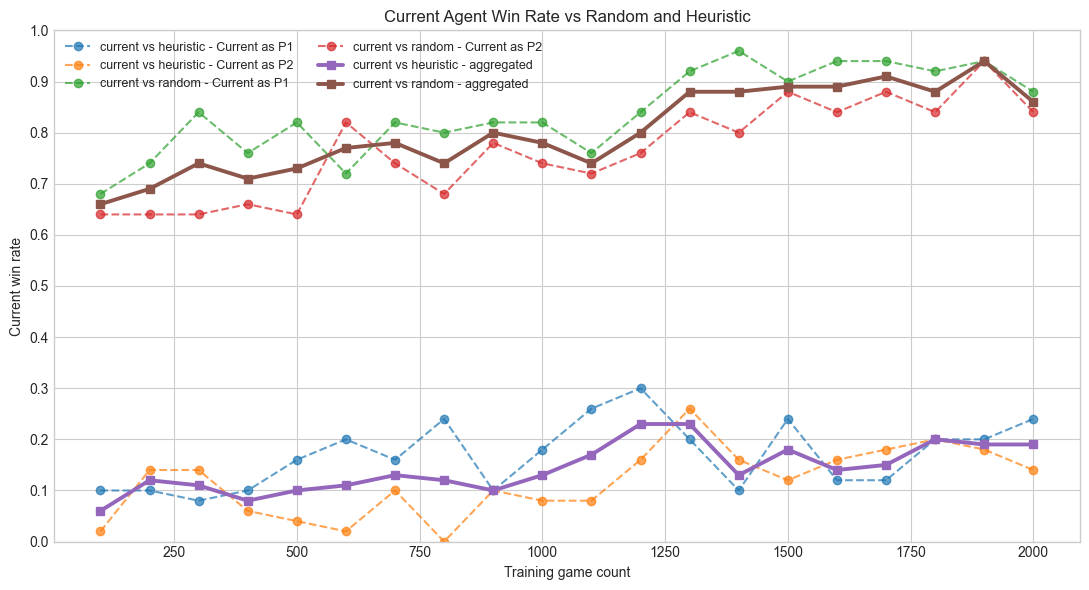

In [ ]:
# Plot 1: current vs random/heuristic with BOTH directional and aggregated rates.
fig, ax = plt.subplots(figsize=(11, 6))

plot_matchups = ["current vs random", "current vs heuristic"]
plot_df_raw = df_raw[df_raw["matchup"].isin(plot_matchups)].copy()
plot_df_agg = df_agg[df_agg["matchup"].isin(plot_matchups)].copy()

# Directional rates: current as P1 and current as P2 (50 games each).
plot_df_raw["perspective"] = np.where(plot_df_raw["p1"] == "current", "Current as P1", "Current as P2")
for (matchup, perspective), group in plot_df_raw.groupby(["matchup", "perspective"]):
    ax.plot(
        group["checkpoint"],
        group["current_win_rate"],
        marker="o",
        linestyle="--",
        alpha=0.7,
        label=f"{matchup} - {perspective}",
    )

# Aggregated rate across both directions (100 games).
for matchup, group in plot_df_agg.groupby("matchup"):
    ax.plot(
        group["checkpoint"],
        group["current_win_rate"],
        marker="s",
        linewidth=2.8,
        label=f"{matchup} - aggregated",
    )

ax.set_title("Current Agent Win Rate vs Random and Heuristic")
ax.set_xlabel("Training game count")
ax.set_ylabel("Current win rate")
ax.set_ylim(0.0, 1.0)
ax.set_yticks(np.arange(0.0, 1.01, 0.1))
ax.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.show()

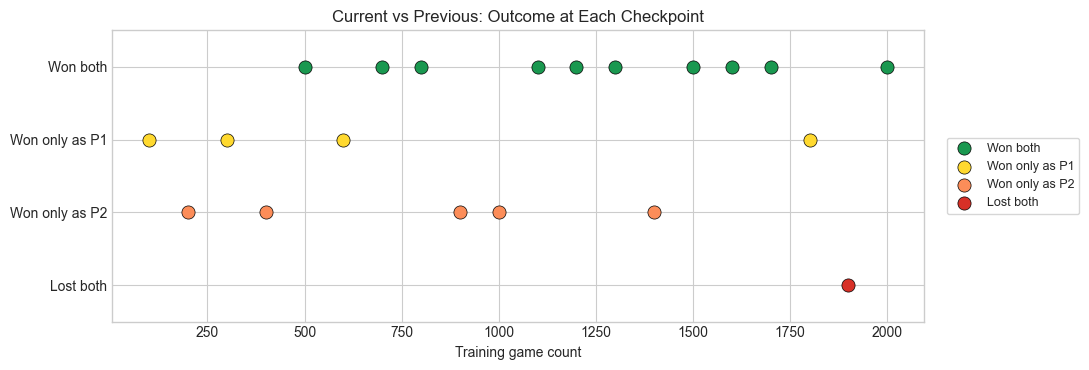

perspective,checkpoint,state_label,win_as_p1,win_as_p2
0,100,Won only as P1,1,0
1,200,Won only as P2,0,1
2,300,Won only as P1,1,0
3,400,Won only as P2,0,1
4,500,Won both,1,1
5,600,Won only as P1,1,0
6,700,Won both,1,1
7,800,Won both,1,1
8,900,Won only as P2,0,1
9,1000,Won only as P2,0,1


In [75]:
# Plot 2: four-state checkpoint outcome for current vs previous.
# States per checkpoint:
#   - Lost both
#   - Won only as P1
#   - Won only as P2
#   - Won both

cvp_rows = df_raw[df_raw["matchup"] == "current vs previous"].copy()
cvp_rows["perspective"] = np.where(cvp_rows["p1"] == "current", "P1", "P2")
cvp_rows["win_indicator"] = (cvp_rows["current_wins"] > cvp_rows["opponent_wins"]).astype(int)

state_df = (
    cvp_rows.pivot(index="checkpoint", columns="perspective", values="win_indicator")
    .rename(columns={"P1": "win_as_p1", "P2": "win_as_p2"})
    .reset_index()
)

state_df["state_code"] = state_df["win_as_p1"] * 2 + state_df["win_as_p2"]
state_labels = {
    0: "Lost both",
    1: "Won only as P2",
    2: "Won only as P1",
    3: "Won both",
}
state_df["state_label"] = state_df["state_code"].map(state_labels)

# Color map by 4-state outcome.
state_colors = {
    0: "#d73027",  # red
    1: "#fc8d59",  # orange
    2: "#ffd92f",  # yellow
    3: "#1a9850",  # green
}

fig, ax = plt.subplots(figsize=(11, 3.8))
for code in [0, 1, 2, 3]:
    g = state_df[state_df["state_code"] == code]
    ax.scatter(
        g["checkpoint"],
        g["state_code"],
        s=90,
        color=state_colors[code],
        edgecolor="black",
        linewidth=0.5,
        label=state_labels[code],
    )

ax.set_title("Current vs Previous: Outcome at Each Checkpoint")
ax.set_xlabel("Training game count")
ax.set_ylabel("")
ax.set_yticks([0, 1, 2, 3])
ax.set_yticklabels([state_labels[i] for i in [0, 1, 2, 3]])
ax.set_ylim(-0.5, 3.5)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], ncol=1, fontsize=9, loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=True)

plt.tight_layout()
plt.show()

state_df[["checkpoint", "state_label", "win_as_p1", "win_as_p2"]]